**PROBLEM STATEMEMENT**: In this project, we analyze player performance data from the ICC Men's T20 World Cup 2026. The dataset includes key statistics such as matches played, runs, wickets, averages, strike rate, and fielding records.

The goal is to clean and analyze the data to identify the best playing XI based on player performance in the tournament.

**THE DATA CONTAINS INFORMATION LIKE**- matches played, runs, wickets, average, strike rate, catches, etc.

**BASIC ON THESE DATA POINTS**- we will try to create the best playing XI from this set of players from the current campaign.
we can summarise our analysis in the following steps:
1. Extraction and loading of the data.
2. Cleaning the data and removing noise.
3. Analyzing the data using different parameters.
4. Visualizing key statistical insights.
5. Selecting the best playing XI based on player performance in the ICC Men's T20 World Cup 2026.

# Import Libraries

In [1]:
# Importing Pandas, NumPy, Matplotlib and Seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the Dataset




In [2]:
# Load the dataset from the CSV file into a pandas DataFrame
data = pd.read_csv("T20WC2026.csv")

In [3]:
# Display the first 5 rows of the dataset
data.head()

,Player Name,Player_Type,Matches_Played,Runs,Average,Strike_Rate,Wickets,Bowling_average,Economy,Bowling_Strike_Rate,Catches
0,Sahibzada Farhan (PAK),Batter,7,383.0,76.6,160.25,NaN,NaN,NaN,NaN,NaN
1,TL Seifert (NZ),Keeper,9,326.0,46.57,166.32,NaN,NaN,NaN,NaN,7.0
2,SV Samson (IND),Keeper,5,321.0,80.25,199.37,NaN,NaN,NaN,NaN,3.0
3,Ishan Kishan (IND),Keeper,9,317.0,35.22,193.29,NaN,NaN,NaN,NaN,9.0
4,FH Allen (NZ),Batter,9,298.0,49.66,200.00,NaN,NaN,NaN,NaN,2.0


# Inspect the Dataset

In [4]:
# Check dataset summary and data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Player Name          209 non-null    object 
 1   Player_Type          209 non-null    object 
 2   Matches_Played       209 non-null    int64  
 3   Runs                 150 non-null    float64
 4   Average              150 non-null    object 
 5   Strike_Rate          150 non-null    float64
 6   Wickets              100 non-null    float64
 7   Bowling_average      100 non-null    float64
 8   Economy              100 non-null    float64
 9   Bowling_Strike_Rate  100 non-null    float64
 10  Catches              17 non-null     float64
dtypes: float64(7), int64(1), object(3)
memory usage: 18.1+ KB


In [5]:
# Check the number of missing values in each column
data.isna().sum()

,0
Player Name,0
Player_Type,0
Matches_Played,0
Runs,59
Average,59
Strike_Rate,59
Wickets,109
Bowling_average,109
Economy,109
Bowling_Strike_Rate,109


# Data Cleaning

In [6]:
# Convert statistical columns to numeric and replace missing values.

cols = [
    "Runs","Average","Strike_Rate",
    "Wickets","Bowling_average",
    "Economy","Bowling_Strike_Rate","Catches"
]

data[cols] = data[cols].apply(pd.to_numeric, errors="coerce")

data = data.fillna(0)

# Role-Based Player Analysis

In [7]:
# Batter Analysis
# Selected batters with strong batting performance
# Criteria: Batting Average ≥ 30 and Runs ≥ 150

Batters = data.loc[data["Player_Type"] == "Batter",
                   ['Player Name','Matches_Played','Runs','Average','Strike_Rate']]

top_batters = Batters.loc[(Batters["Average"] >= 30) & (Batters["Runs"] >= 150)]

top_batters_runs = top_batters.sort_values("Runs", ascending=False)
top_batters_runs.head(10)

,Player Name,Matches_Played,Runs,Average,Strike_Rate
0,Sahibzada Farhan (PAK),7,383.0,76.60,160.25
4,FH Allen (NZ),9,298.0,49.66,200.00
5,BJ Bennett (ZIM),6,292.0,146.00,134.56
6,AK Markram (SA),8,286.0,47.66,165.31
7,JG Bethell (ENG),8,280.0,35.00,152.17
8,SO Hetmyer (WI),7,248.0,41.33,186.46
9,SA Yadav (IND),9,242.0,30.25,136.72
15,SD Hope (WI),7,217.0,36.16,130.72
16,P Nissanka (SL),7,211.0,35.16,147.55
20,P Rathnayake (SL),7,205.0,34.16,154.13


In [8]:
# Bowler Analysis
# Selected bowlers with effective bowling performance
# Criteria: Bowling Average ≤ 20 and Wickets ≥ 7

Bowlers = data.loc[data["Player_Type"] == "Bowler",
                   ['Player Name','Matches_Played','Wickets',
                    'Bowling_average','Economy','Bowling_Strike_Rate']]

top_bowlers = Bowlers.loc[(Bowlers["Bowling_average"] <= 20) & (Bowlers["Wickets"] >= 7)]

top_bowlers_wickets = top_bowlers.sort_values("Wickets", ascending=False)
top_bowlers_wickets.head(10)

,Player Name,Matches_Played,Wickets,Bowling_average,Economy,Bowling_Strike_Rate
150,JJ Bumrah (IND),8,14.0,12.42,6.21,12.00
152,SC van Schalkwyk (USA),4,13.0,7.76,6.80,6.84
153,B Muzarabani (ZIM),6,13.0,14.46,7.88,11.00
154,AU Rashid (ENG),8,13.0,19.23,8.15,14.15
155,L Ngidi (SA),7,12.0,15.58,7.19,13.00
156,M Theekshana (SL),7,11.0,18.54,7.41,15.00
157,C Bosch (SA),7,11.0,17.36,7.64,13.63
161,G Motie (WI),7,10.0,17.30,7.86,13.20
159,Usman Tariq (PAK),6,10.0,14.10,7.23,11.70
163,PVD Chameera (SL),6,10.0,20.00,9.52,12.60


In [9]:
# Keeper Analysis
# Selected wicket-keepers with consistent batting performance
# Criteria: Batting Average ≥ 25

Keepers = data.loc[data["Player_Type"] == "Keeper",
                   ['Player Name','Matches_Played','Runs',
                    'Average','Strike_Rate','Catches']]

top_keepers = Keepers.loc[Keepers["Average"] >= 25]

top_keepers_runs = top_keepers.sort_values("Runs", ascending=False)
top_keepers_runs.head()

,Player Name,Matches_Played,Runs,Average,Strike_Rate,Catches
1,TL Seifert (NZ),9,326.0,46.57,166.32,7.0
2,SV Samson (IND),5,321.0,80.25,199.37,3.0
3,Ishan Kishan (IND),9,317.0,35.22,193.29,9.0
12,RD Rickelton (SA),8,228.0,32.57,170.14,0.0
78,JP Inglis (AUS),4,84.0,28.00,171.42,0.0


In [10]:
# Allrounder Analysis
# Selected players contributing in both batting and bowling
# Criteria: Runs ≥ 120 and Wickets ≥ 6

Allrounders = data.loc[data["Player_Type"] == "Allrounder"]

top_allrounders = Allrounders.loc[
    (Allrounders["Runs"] >= 120) &
    (Allrounders["Wickets"] >= 6)
]

top_allrounders.head()

,Player Name,Player_Type,Matches_Played,Runs,Average,Strike_Rate,Wickets,Bowling_average,Economy,Bowling_Strike_Rate,Catches
13,WG Jacks (ENG),Allrounder,8,226.0,56.50,176.56,9.0,21.66,9.75,13.33,0.0
14,HH Pandya (IND),Allrounder,9,217.0,27.12,160.74,9.0,32.33,8.81,22.00,0.0
28,SM Curran (ENG),Allrounder,8,167.0,23.85,120.14,6.0,34.16,9.46,21.66,0.0
37,JO Holder (WI),Allrounder,7,141.0,35.25,174.07,10.0,20.40,8.86,13.80,0.0
47,R Ravindra (NZ),Allrounder,9,129.0,25.80,134.37,12.0,12.41,7.84,9.50,2.0


# Select the Best Playing XI

In [11]:
# Select top players from each role to build the Best Playing XI
# 3 Batters, 2 Keepers, 2 Allrounders, and 4 Bowlers

best_batters = top_batters_runs.head(3)
best_keeper = top_keepers_runs.head(2)
best_allrounders = top_allrounders.head(2)
best_bowlers = top_bowlers_wickets.head(4)

In [12]:
# Select players for the Best Playing XI
# add role column

best_batters["Role"] = "Batter"
best_keeper["Role"] = "Keeper"
best_allrounders["Role"] = "Allrounder"
best_bowlers["Role"] = "Bowler"

# combine players
best_xi = pd.concat([
    best_batters,
    best_keeper,
    best_allrounders,
    best_bowlers
])

# define role order
role_order = ["Batter","Keeper","Allrounder","Bowler"]

best_xi["Role"] = pd.Categorical(best_xi["Role"], categories=role_order, ordered=True)

# sort by role
best_xi = best_xi.sort_values("Role")

best_xi[["Player Name","Role"]]

/tmp/ipykernel_2130/2756983040.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_batters["Role"] = "Batter"
/tmp/ipykernel_2130/2756983040.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_keeper["Role"] = "Keeper"
/tmp/ipykernel_2130/2756983040.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/ind

,Player Name,Role
0,Sahibzada Farhan (PAK),Batter
4,FH Allen (NZ),Batter
5,BJ Bennett (ZIM),Batter
1,TL Seifert (NZ),Keeper
2,SV Samson (IND),Keeper
13,WG Jacks (ENG),Allrounder
14,HH Pandya (IND),Allrounder
150,JJ Bumrah (IND),Bowler
152,SC van Schalkwyk (USA),Bowler
153,B Muzarabani (ZIM),Bowler


In [13]:
# Select players for the Best Playing XI

# make proper copies (fix SettingWithCopyWarning)
best_batters = best_batters.copy()
best_keeper = best_keeper.copy()
best_allrounders = best_allrounders.copy()
best_bowlers = best_bowlers.copy()

# assign roles safely
best_batters.loc[:, "Role"] = "Batter"
best_keeper.loc[:, "Role"] = "Keeper"
best_allrounders.loc[:, "Role"] = "Allrounder"
best_bowlers.loc[:, "Role"] = "Bowler"

# combine players
best_xi = pd.concat([
    best_batters,
    best_keeper,
    best_allrounders,
    best_bowlers
], ignore_index=True)

# define role order
role_order = ["Batter", "Keeper", "Allrounder", "Bowler"]

best_xi["Role"] = pd.Categorical(
    best_xi["Role"],
    categories=role_order,
    ordered=True
)

# sort by role
best_xi = best_xi.sort_values("Role")

# final output
best_xi[["Player Name", "Role"]]

,Player Name,Role
0,Sahibzada Farhan (PAK),Batter
1,FH Allen (NZ),Batter
2,BJ Bennett (ZIM),Batter
3,TL Seifert (NZ),Keeper
4,SV Samson (IND),Keeper
5,WG Jacks (ENG),Allrounder
6,HH Pandya (IND),Allrounder
7,JJ Bumrah (IND),Bowler
8,SC van Schalkwyk (USA),Bowler
9,B Muzarabani (ZIM),Bowler


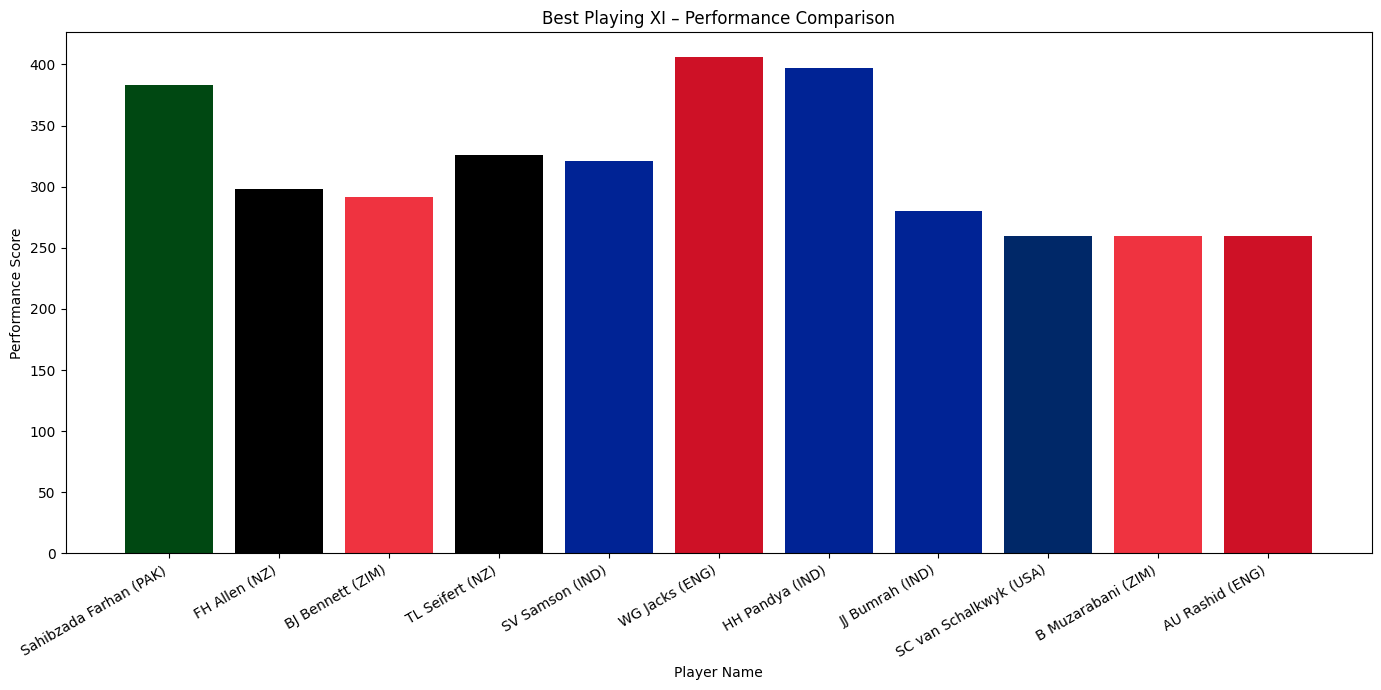

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# matplotlib to default white style
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

# Assign roles to players (Batter, Keeper, Allrounder, Bowler)
best_batters = best_batters.copy()
best_keeper = best_keeper.copy()
best_allrounders = best_allrounders.copy()
best_bowlers = best_bowlers.copy()

best_batters["Role"] = "Batter"
best_keeper["Role"] = "Keeper"
best_allrounders["Role"] = "Allrounder"
best_bowlers["Role"] = "Bowler"

# combine players
best_xi = pd.concat([
    best_batters,
    best_keeper,
    best_allrounders,
    best_bowlers
], ignore_index=True)

# performance score
best_xi["Performance"] = best_xi["Runs"].fillna(0) + best_xi["Wickets"].fillna(0) * 20

# extract team
best_xi["Team"] = best_xi["Player Name"].str.extract(r"\((.*?)\)")

# jersey colors
team_colors = {
    "IND": "#002395","SL": "#004B87","PAK": "#004812","AUS": "#005221",
    "ENG": "#CE1126","SA": "#FFCD00","NZ": "#000000","WI": "#7B0041",
    "NED": "#FF4F00","AFG": "#1C5D9C","USA": "#002868","IRE": "#009A44",
    "SCOT": "#4B0082","ZIM": "#EF3340","NAM": "#003580","NEP": "#003893",
    "OMA": "#D21034","UAE": "#00732F","CAN": "#000000","ITA": "#0047AB"
}

# map colors
best_xi["Color"] = best_xi["Team"].map(team_colors).fillna("#888888")

# role order
role_order = ["Batter","Keeper","Allrounder","Bowler"]
best_xi["Role"] = pd.Categorical(best_xi["Role"], categories=role_order, ordered=True)

# sort players
best_xi = best_xi.sort_values(["Role","Performance"], ascending=[True,False])

# -------- PLOT --------
plt.figure(figsize=(14,7))

plt.bar(
    best_xi["Player Name"],
    best_xi["Performance"],
    color=best_xi["Color"]
)

plt.xlabel("Player Name")
plt.ylabel("Performance Score")
plt.title("Best Playing XI – Performance Comparison")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

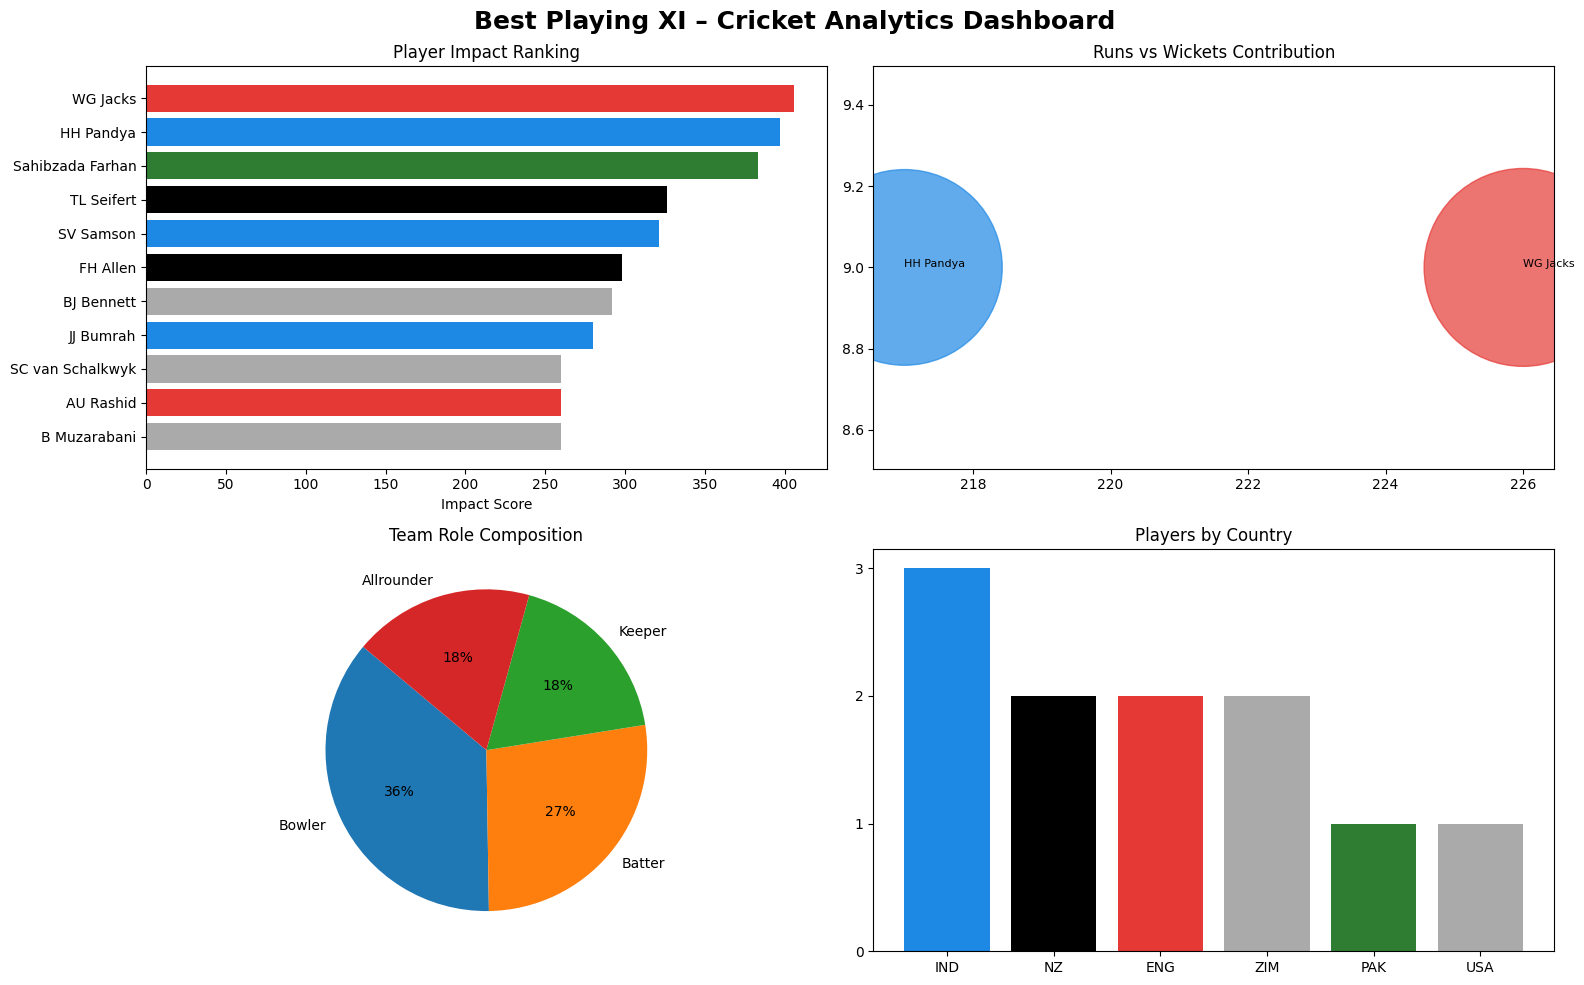

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator # Import this for integer ticks

plt.style.use("default")

# 1. Logic Processing
best_xi["Performance"] = best_xi["Runs"].fillna(0) + best_xi["Wickets"].fillna(0)*20
best_xi["Team"] = best_xi["Player Name"].str.extract(r"\((.*?)\)")
best_xi["Player"] = best_xi["Player Name"].str.replace(r"\(.*\)", "", regex=True).str.strip()

team_colors = {
    "IND": "#1E88E5", "AUS": "#43A047", "ENG": "#E53935",
    "PAK": "#2E7D32", "NZ": "#000000", "SA": "#FDD835", "WI": "#8E24AA"
}
best_xi["Color"] = best_xi["Team"].map(team_colors).fillna("#AAAAAA")

fig = plt.figure(figsize=(16, 10))

# ---------------- Impact Ranking ----------------
ax1 = plt.subplot(221)
data = best_xi.sort_values("Performance")
ax1.barh(data["Player"], data["Performance"], color=data["Color"])
ax1.set_title("Player Impact Ranking")
ax1.set_xlabel("Impact Score")

# ---------------- Runs vs Wickets ----------------
ax2 = plt.subplot(222)
ax2.scatter(best_xi["Runs"], best_xi["Wickets"], s=best_xi["Performance"]*50, c=best_xi["Color"], alpha=0.7)
for i, row in best_xi.iterrows():
    ax2.text(row["Runs"], row["Wickets"], row["Player"], fontsize=8)
ax2.set_title("Runs vs Wickets Contribution")

# ---------------- Role Contribution ----------------
ax3 = plt.subplot(223)
if "Role" in best_xi.columns:
    role_counts = best_xi["Role"].value_counts()
    ax3.pie(role_counts, labels=role_counts.index, autopct="%1.0f%%", startangle=140)
    ax3.set_title("Team Role Composition")

# ---------------- Team Distribution (FIXED FOR INTEGERS) ----------------
ax4 = plt.subplot(224)
team_counts = best_xi["Team"].value_counts()

# Apply colors to the team bars to match the rest of the chart
colors_for_bars = [team_colors.get(team, "#AAAAAA") for team in team_counts.index]

ax4.bar(team_counts.index, team_counts.values, color=colors_for_bars)
ax4.set_title("Players by Country")

# This line removes the decimals (1.5, 2.5 etc.)
ax4.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.suptitle("Best Playing XI – Cricket Analytics Dashboard", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

## Captain and Vice-Captain

To select the Captain and Vice-Captain, we calculate an overall **player impact score** using key stats like **Runs, Strike Rate, Batting Average, Wickets, and Economy Rate**.

Since these statistics are on different scales, we standardize them using the **cp-score method** so that players can be compared fairly.

Based on the final **Impact Score**, the player with the **highest score is selected as the Captain**, and the player with the **second highest score becomes the Vice-Captain**.

In [16]:
import numpy as np

# calculate cp-scores
best_xi["Runs_cp"] = (best_xi["Runs"] - best_xi["Runs"].mean()) / best_xi["Runs"].std()
best_xi["SR_cp"] = (best_xi["Strike_Rate"] - best_xi["Strike_Rate"].mean()) / best_xi["Strike_Rate"].std()
best_xi["Avg_cp"] = (best_xi["Average"] - best_xi["Average"].mean()) / best_xi["Average"].std()
best_xi["Wkts_cp"] = (best_xi["Wickets"] - best_xi["Wickets"].mean()) / best_xi["Wickets"].std()

# invert economy (lower is better)
best_xi["Eco_cp"] = -(best_xi["Economy"] - best_xi["Economy"].mean()) / best_xi["Economy"].std()

# overall impact score
best_xi["Impact_Score"] = (
    best_xi["Runs_cp"] +
    best_xi["SR_cp"] +
    best_xi["Avg_cp"] +
    best_xi["Wkts_cp"] +
    best_xi["Eco_cp"]
)

# select captain and vice captain
cv = best_xi.nlargest(2, "Impact_Score")

captain = cv.iloc[0]["Player Name"]
vice_captain = cv.iloc[1]["Player Name"]

print("Captain:", captain)
print("Vice-Captain:", vice_captain)

Captain: WG Jacks (ENG)
Vice-Captain: HH Pandya (IND)


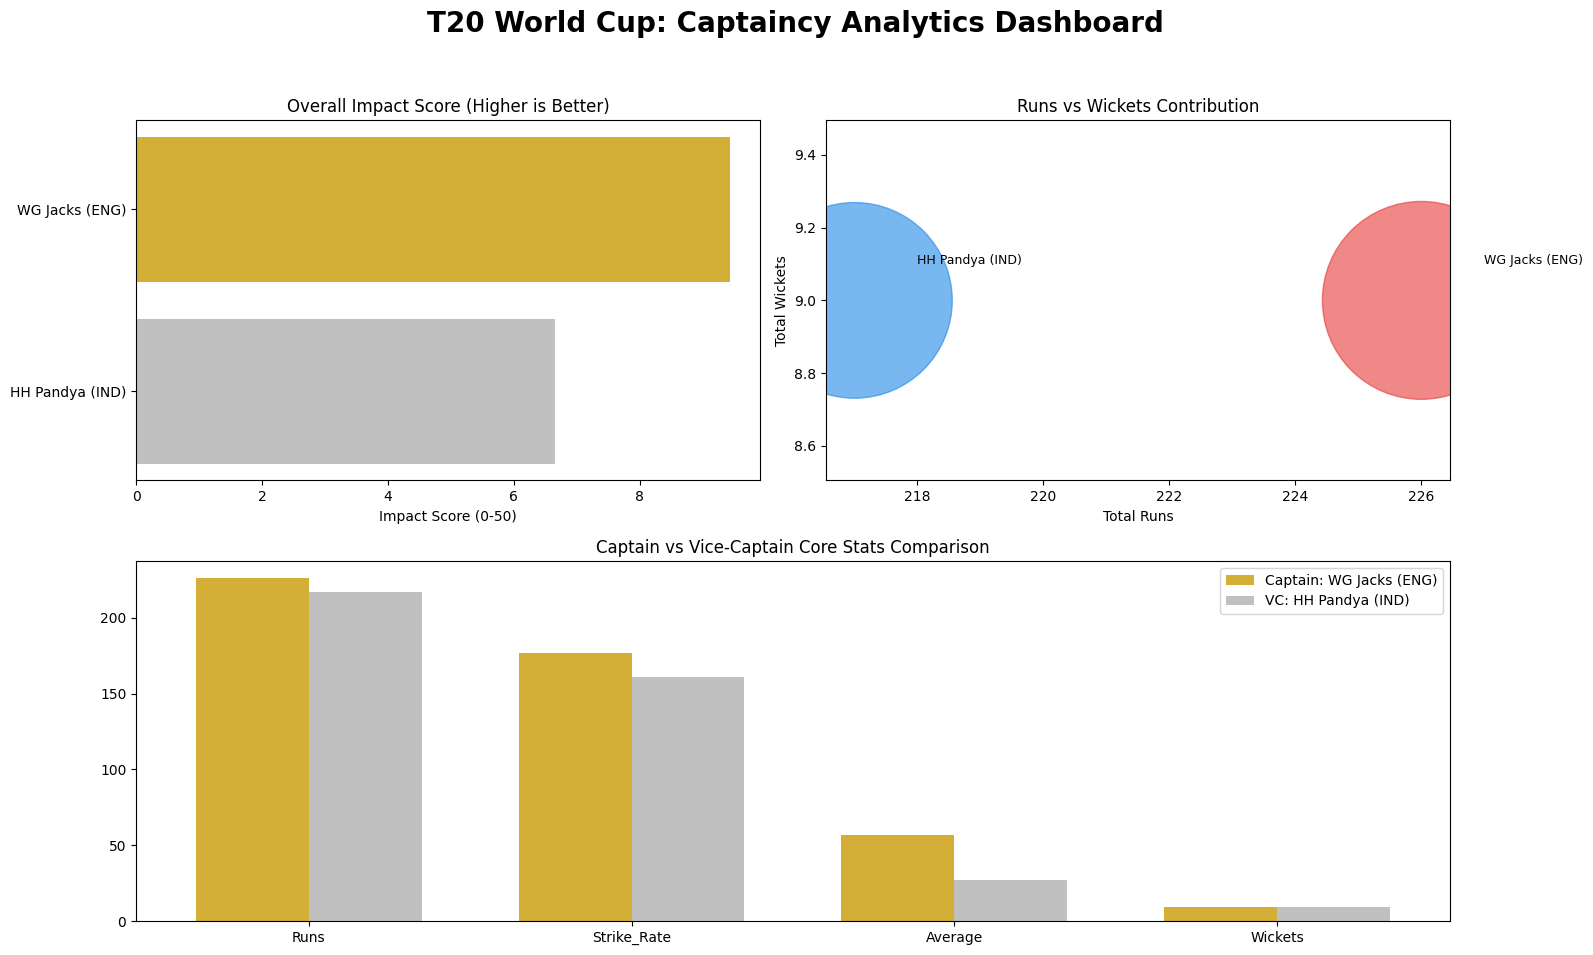

Captain: WG Jacks (ENG), Vice Captain: HH Pandya (IND)


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Scaling Logic (Fixes the negative bar issue)
def scale_stat(series, invert=False):
    if series.max() == series.min(): return series * 0 + 5 # Handle edge case
    if invert: # For Economy: Lower is better
        return 10 * (series.max() - series) / (series.max() - series.min())
    return 10 * (series - series.min()) / (series.max() - series.min())

# Apply scaling to create a positive Impact_Score
best_xi["Runs_score"] = scale_stat(best_xi["Runs"])
best_xi["SR_score"]   = scale_stat(best_xi["Strike_Rate"])
best_xi["Avg_score"]  = scale_stat(best_xi["Average"])
best_xi["Wkts_score"] = scale_stat(best_xi["Wickets"])
best_xi["Eco_score"]  = scale_stat(best_xi["Economy"], invert=True)

best_xi["Impact_Score"] = (
    best_xi["Runs_score"] + best_xi["SR_score"] +
    best_xi["Avg_score"] + best_xi["Wkts_score"] + best_xi["Eco_score"]
)

# 2. Identify Captain & Vice-Captain
ranked = best_xi.sort_values("Impact_Score", ascending=False)
captain = ranked.iloc[0]["Player Name"]
vice_captain = ranked.iloc[1]["Player Name"]

# 3. Initialize Dashboard Layout
fig = plt.figure(figsize=(16, 10))

# -------- Subplot 1: Impact Ranking (Horizontal Bars) --------
ax1 = plt.subplot(221)
colors = []
for name in ranked["Player Name"]:
    if name == captain: colors.append("#D4AF37") # Gold
    elif name == vice_captain: colors.append("#C0C0C0") # Silver
    else: colors.append("#90A4AE") # Grey

ax1.barh(ranked["Player Name"], ranked["Impact_Score"], color=colors)
ax1.set_title("Overall Impact Score (Higher is Better)")
ax1.set_xlabel("Impact Score (0-50)")
ax1.invert_yaxis() # Put Captain at the top

# -------- Subplot 2: Runs vs Wickets (Scatter) --------
ax2 = plt.subplot(222)
ax2.scatter(
    best_xi["Runs"],
    best_xi["Wickets"],
    s=best_xi["Performance"]*50,
    c=best_xi["Color"] if "Color" in best_xi.columns else 'blue',
    alpha=0.6
)

for i, row in best_xi.iterrows():
    ax2.text(row["Runs"]+1, row["Wickets"]+0.1, row["Player Name"], fontsize=9)

ax2.set_title("Runs vs Wickets Contribution")
ax2.set_xlabel("Total Runs")
ax2.set_ylabel("Total Wickets")

# -------- Subplot 3: Captain vs Vice-Captain (Side-by-Side) --------
ax3 = plt.subplot(2, 2, (3, 4)) # Spans across the bottom
metrics = ["Runs", "Strike_Rate", "Average", "Wickets"]

# Get stats for C and VC
c_stats = best_xi[best_xi["Player Name"] == captain][metrics].values[0]
vc_stats = best_xi[best_xi["Player Name"] == vice_captain][metrics].values[0]

x = np.arange(len(metrics))
width = 0.35

ax3.bar(x - width/2, c_stats, width, label=f"Captain: {captain}", color="#D4AF37")
ax3.bar(x + width/2, vc_stats, width, label=f"VC: {vice_captain}", color="#C0C0C0")

ax3.set_xticks(x)
ax3.set_xticklabels(metrics)
ax3.set_title("Captain vs Vice-Captain Core Stats Comparison")
ax3.legend()

# Final Dashboard Formatting
plt.suptitle("T20 World Cup: Captaincy Analytics Dashboard", fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"Captain: {captain}, Vice Captain: {vice_captain}")






## If you want a Rule-Based Captain and Vice-Captain Selection

The Captain is selected from **Batters or Keepers** with strong batting performance (Average ≥ 50, Strike Rate ≥ 180, Runs ≥ 300).  
The player with the **highest runs** among them is chosen as the Captain.

The Vice-Captain is selected from **All-rounders** who perform well in both batting and bowling (Average ≥ 30, Strike Rate ≥ 150, Runs ≥ 200, Wickets ≥ 8).  
The player with the **highest runs and wicket** among them becomes the Vice-Captain.

In [18]:
# Captain: Batter or Keeper with strong batting stats
captain_df = best_xi[
    (best_xi["Role"].isin(["Batter","Keeper"])) &
    (best_xi["Average"] >= 50) &
    (best_xi["Strike_Rate"] >= 180) &
    (best_xi["Runs"] >= 300)
]

captain = captain_df.nlargest(1, "Runs")["Player Name"].values[0]


# Vice Captain: Allrounder with batting + bowling impact
vc_df = best_xi[
    (best_xi["Role"] == "Allrounder") &
    (best_xi["Average"] >= 30) &
    (best_xi["Strike_Rate"] >= 150) &
    (best_xi["Runs"] >= 200) &
    (best_xi["Wickets"] >= 8)
]

vice_captain = vc_df.nlargest(1, "Runs")["Player Name"].values[0]


print("Captain:", captain)
print("Vice Captain:", vice_captain)

Captain: SV Samson (IND)
Vice Captain: WG Jacks (ENG)


In [19]:
# -------- FINAL RESULT --------

# combine all players
final_xi = pd.concat([
    best_batters,
    best_keeper,
    best_allrounders,
    best_bowlers
], ignore_index=True)

print("🏏 2026 T20 World Cup Best Playing XI 🏏\n")

# print playing XI
for i, player in enumerate(final_xi["Player Name"], start=1):
    print(f"{i}. {player}")

print("\n----------------------------------")

# captain and vice captain
print(f"Captain: {captain}")
print(f"Vice-Captain: {vice_captain}")

print("\n 🏏Final Playing XI Selected Using Data Analysis🏏")

🏏 2026 T20 World Cup Best Playing XI 🏏

1. Sahibzada Farhan (PAK)
2. FH Allen (NZ)
3. BJ Bennett (ZIM)
4. TL Seifert (NZ)
5. SV Samson (IND)
6. WG Jacks (ENG)
7. HH Pandya (IND)
8. JJ Bumrah (IND)
9. SC van Schalkwyk (USA)
10. B Muzarabani (ZIM)
11. AU Rashid (ENG)

----------------------------------
Captain: SV Samson (IND)
Vice-Captain: WG Jacks (ENG)

 🏏Final Playing XI Selected Using Data Analysis🏏
